In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Load the CSV file
def load_data(file_path):
    """Load the dataset from a CSV file"""
    try:
        df = pd.read_csv(file_path)
        print(f"Successfully loaded data from {file_path}")
        return df
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return None

file_path = "fed_rd_year&gdp.csv"
df = load_data(file_path)

if df is not None:
    print(f"\nDataset shape: {df.shape}")
    print("\nFirst few rows:")
    print(df.head())
    print("\nColumn names:")
    print(df.columns.tolist())


Successfully loaded data from fed_rd_year&gdp.csv

Dataset shape: (14, 43)

First few rows:
  department  1976_gdp1790000000000.0  1977_gdp2028000000000.0  \
0        DHS                      NaN                      NaN   
1        DOC             8.190000e+08             8.370000e+08   
2        DOD             3.569600e+10             3.796700e+10   
3        DOE             1.088200e+10             1.374100e+10   
4        DOT             1.142000e+09             1.095000e+09   

   1978_gdp2278000000000.0  1979_gdp2570000000000.0  1980_gdp2797000000000.0  \
0                      NaN                      NaN                      NaN   
1             8.710000e+08             9.520000e+08             9.450000e+08   
2             3.702200e+10             3.717400e+10             3.700500e+10   
3             1.566300e+10             1.561200e+10             1.522600e+10   
4             1.156000e+09             1.004000e+09             1.048000e+09   

   1981_gdp3138000000000.0  19

In [ ]:
# Transform Data to Tidy Format
def transform_data(df):
    """Transform dataset from wide to long (tidy) format"""
    # Melt converts year columns into rows
    df_melted = df.melt(
            id_vars=["department"],
            var_name="Year_GDP",
            value_name="Budget"
        )
        
    # Extract year from the Year_GDP column using regex
    df_melted["Year"] = df_melted["Year_GDP"].str.extract(r'(\d{4})').astype(int)
        
     # Drop the combined Year_GDP column
    df_melted = df_melted.drop(columns=["Year_GDP"])
        
     # Remove rows with missing Budget values
    df_melted = df_melted.dropna()
        
    # Convert Budget to numeric (handle any non-numeric values)
    df_melted["Budget"] = pd.to_numeric(df_melted["Budget"], errors='coerce')
        
    # Remove any rows where Budget is NaN after conversion
    df_melted = df_melted.dropna(subset=["Budget"])
        
    print("\nData transformation complete!")
    return df_melted
df_melted = transform_data(df)
    
print("\nTidy data (first 10 rows):")
print(df_melted.head(10))
print(f"\nNew shape: {df_melted.shape}")


Data transformation complete!

Tidy data (first 10 rows):
   department        Budget  Year
1         DOC  8.190000e+08  1976
2         DOD  3.569600e+10  1976
3         DOE  1.088200e+10  1976
4         DOT  1.142000e+09  1976
5         EPA  9.680000e+08  1976
6         HHS  9.226000e+09  1976
7    Interior  1.152000e+09  1976
8        NASA  1.251300e+10  1976
9         NIH  8.025000e+09  1976
10        NSF  2.372000e+09  1976

New shape: (562, 3)


In [ ]:
# Exploratory Data Analysis    
print("\nSummary statistics of Budget column:") # Summary stats for the Budget column
print(df_melted["Budget"].describe()) 
    
print("\nUnique years in dataset:")
print(sorted(df_melted["Year"].unique()))
    
print("\nDepartments in dataset:")
print(df_melted["department"].unique())



Summary statistics of Budget column:
count    5.620000e+02
mean     1.083262e+10
std      1.813250e+10
min      3.130000e+08
25%      9.605000e+08
50%      2.155000e+09
75%      1.235450e+10
max      9.432500e+10
Name: Budget, dtype: float64

Unique years in dataset:
[np.int64(1976), np.int64(1977), np.int64(1978), np.int64(1979), np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Departments in dataset:
['DOC' 'DOD' 'DOE' 'DOT' 'EPA' 'H

In [ ]:
# Pivot Table - Aggregation    
budget_by_year = df_melted.pivot_table( # Pivot table to sum budgets by year
        values="Budget",
        index="Year",
        aggfunc="sum"
    )
print("\nTotal Federal R&D Budget by Year:")
print(budget_by_year)
    
budget_by_dept_year = df_melted.pivot_table(
        values="Budget",
        index="department",
        columns="Year",
        aggfunc="sum"
    )
print("\nR&D Budget by Department and Year:")
print(budget_by_dept_year)



Total Federal R&D Budget by Year:
            Budget
Year              
1976  8.622700e+10
1977  9.180700e+10
1978  9.486400e+10
1979  9.660100e+10
1980  9.630500e+10
1981  9.830400e+10
1982  9.544800e+10
1983  9.501000e+10
1984  1.053710e+11
1985  1.148180e+11
1986  1.182310e+11
1987  1.253140e+11
1988  1.268000e+11
1989  1.289120e+11
1990  1.291260e+11
1991  1.300080e+11
1992  1.331720e+11
1993  1.320800e+11
1994  1.272780e+11
1995  1.248830e+11
1996  1.239780e+11
1997  1.270180e+11
1998  1.296980e+11
1999  1.368670e+11
2000  1.422990e+11
2001  1.531970e+11
2002  1.703540e+11
2003  1.920100e+11
2004  1.991040e+11
2005  2.000990e+11
2006  1.994290e+11
2007  2.018270e+11
2008  2.008570e+11
2009  2.012750e+11
2010  2.045560e+11
2011  1.942560e+11
2012  1.889440e+11
2013  1.721210e+11
2014  1.753830e+11
2015  1.746080e+11
2016  1.858850e+11
2017  1.636060e+11

R&D Budget by Department and Year:
Year                1976          1977          1978          1979  \
department             

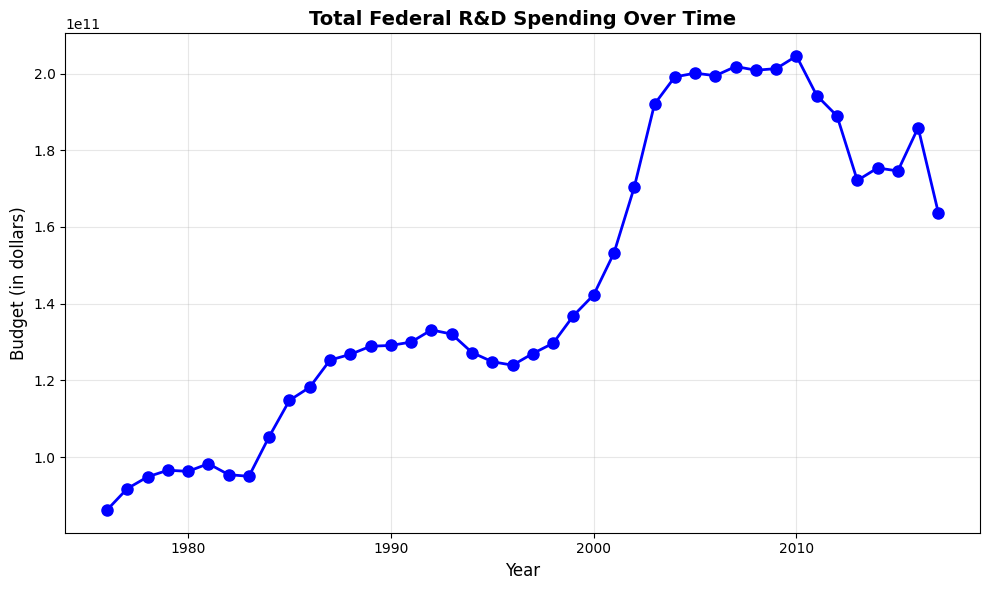

In [ ]:
# Visualization 1: Line Plot of Total Federal R&D Spending Over Time 
plt.figure(figsize=(10, 6))
yearly_budget = df_melted.groupby("Year")["Budget"].sum().reset_index() # Group by year and sum budgets
plt.plot(yearly_budget["Year"], yearly_budget["Budget"], 
             marker="o", linewidth=2, markersize=8, color="blue")
plt.title("Total Federal R&D Spending Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Budget (in dollars)", fontsize=12)
plt.grid(True, alpha=0.3) # Add grid for better readability
plt.tight_layout()
plt.show()


# This line plot graph illustrates the aggregate federal research and development spending from 1976 to 2017. The visualization reveals several key trends:

- **Initial Growth Phase (1976-2004)**: Federal R&D spending shows a steady increase, growing from approximately $8.7 billion to $13.9 billion over this 28-year period.
- **Acceleration Period (2004-2008)**: A sharp increase occurs, with spending nearly doubling from $13.9 billion to over $20 billion, indicating heightened investment in research initiatives.
- **Peak and Decline (2008-2012)**: The data shows a peak around 2008 at approximately $21.5 billion, followed by a significant decline through 2012, dropping to about $17.3 billion. This decline likely reflects the impact of the 2008 financial crisis and subsequent budget constraints.
- **Stabilization (2012-2017)**: After 2012, spending stabilizes and shows modest recovery, ending around $16.4 billion by 2017.


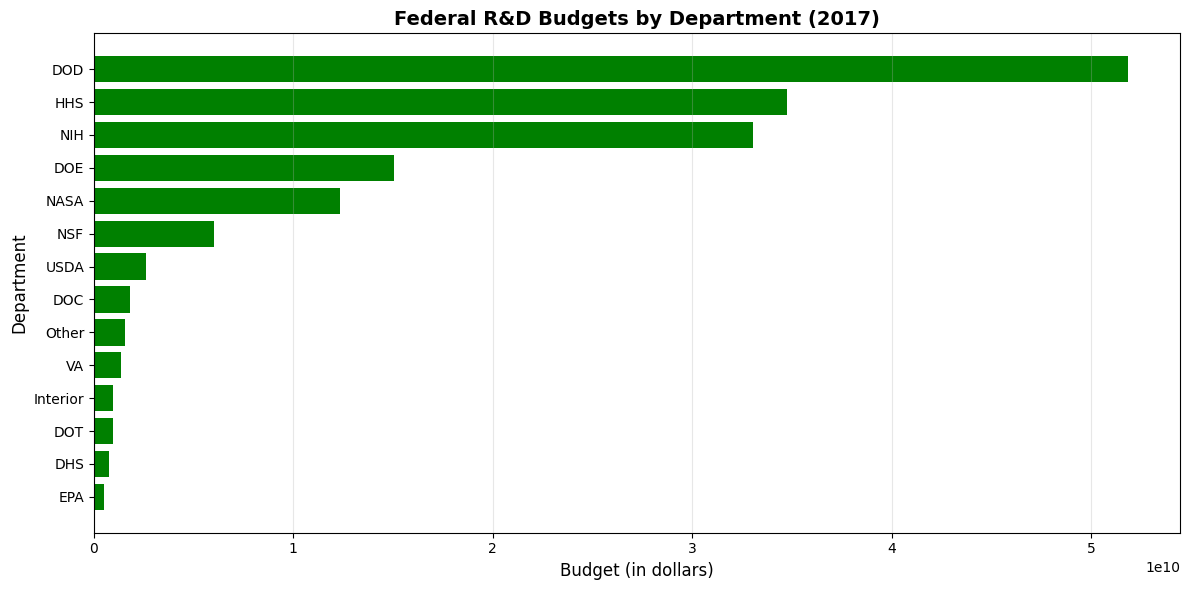

In [ ]:
# Visualization 2: Bar Plot for Latest Year  
latest_year = df_melted["Year"].max()
latest_data = df_melted[df_melted["Year"] == latest_year].sort_values("Budget", ascending=True) # Sort for better visualization
    
plt.figure(figsize=(12, 6))
plt.barh(latest_data["department"], latest_data["Budget"], color="green")
plt.title(f"Federal R&D Budgets by Department ({latest_year})", 
              fontsize=14, fontweight="bold")
plt.xlabel("Budget (in dollars)", fontsize=12)
plt.ylabel("Department", fontsize=12)
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# This horizontal bar chart displays the distribution of federal R&D funding across different departments in 2017, ranked from highest to lowest spending. Key observations include:

- **Defense Dominance**: The Department of Defense (DOD) leads significantly with approximately $50 billion in R&D spending, nearly double that of the second-highest department.
- **Health and Science Research**: The Department of Health and Human Services (HHS) and National Institutes of Health (NIH) are the second and third largest recipients with approximately $41 billion and $35 billion respectively, reflecting strong federal commitment to medical and health research.
- **Energy and Space Exploration**: The Department of Energy (DOE) and NASA receive moderate funding at approximately $17 billion and $14 billion respectively.
- **Smaller Allocations**: Remaining agencies including the National Science Foundation (NSF), USDA, Department of Commerce (DOC), and others receive smaller portions of the R&D budget, each under $10 billion.

This distribution reflects the federal government's priorities in defense, health innovation, and space exploration as primary drivers of research investment.